In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import datetime
from OSDE.LegendreExpSPDensity import LegExp, LegExpSPDensity
from StocProcess.RBM import RBMTransProb, MakeRBMTransProbFunc

In [9]:
# RBM parameters
c = -1
d = 1
x0 = 0.5 * (c + d)
t0 = 0
ts = np.concatenate([[0], np.linspace(0.2, 0.6, 5)])
mu = 0.5
sigma = 1.0
n_terms = 100

maxDeg = 5

In [10]:
legExpResults = []

for i in range(len(ts)-1):
    print(i, datetime.datetime.now())
    transProbFunc = MakeRBMTransProbFunc(ts[i+1], ts[i], c, d, mu, sigma, n_terms)

    if i == 0:
        densFunc = lambda x: transProbFunc(x, x0)
        legExpResults.append(LegExp(densFunc, maxDeg))
    else:
        legExpResults.append(LegExpSPDensity(legExpResults[i-1].fApp, transProbFunc, maxDeg))

0 2025-01-23 09:15:09.056755
1 2025-01-23 09:15:14.330675
2 2025-01-23 09:18:59.220079
3 2025-01-23 09:22:40.783528
4 2025-01-23 09:25:09.704335


In [11]:
xs = np.linspace(c, d, 100)

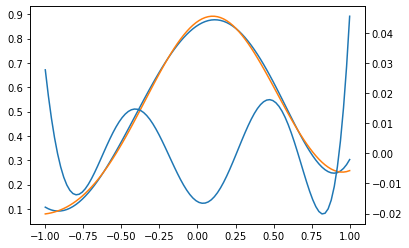

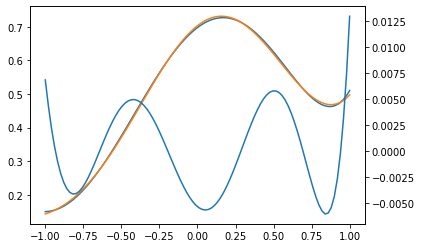

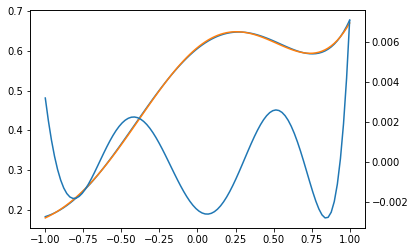

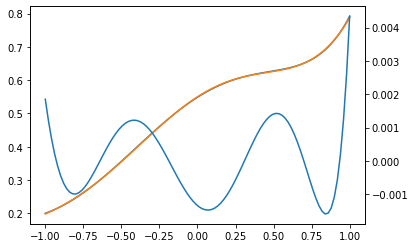

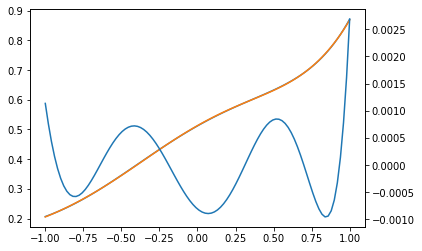

In [12]:
for i in range(len(ts)-1):
    pApp = np.array([legExpResults[i].fApp(x) for x in xs])
    pExa = np.array([RBMTransProb(x, ts[i+1], x0, t0, c, d, mu, sigma, n_terms) for x in xs])
    ax1 = plt.gca()
    ax1.plot(xs, pApp, label="app")
    ax1.plot(xs, pExa, label="exact")
    ax2 = ax1.twinx()
    ax2.plot(xs, pApp - pExa, label="diff")
    plt.show()